
## **literature review**

Customer churn in e-commerce has been widely studied as a multi-factor problem influenced by transaction history, engagement behavior, service quality, and customer satisfaction. Prior research shows that recency, frequency, and monetary patterns remain foundational for churn analysis, while newer studies extend this view by adding browsing behavior, cart abandonment, reviews, support interactions, returns, and loyalty indicators. Customer satisfaction and service quality are consistently linked to continued usage and repurchase intention, whereas friction in the checkout or post-purchase process increases the risk of abandonment and churn. Therefore, this dataset is well suited for churn analysis because it captures both classical RFM-style signals and modern customer-experience variables.

- E-commerce churn research usually says that customers leave when their purchase recency increases, their purchase frequency drops, their transaction value weakens, or their experience becomes poor. That is why RFM-type thinking (Recency, Frequency, Monetary) is one of the most common foundations in churn and customer segmentation studies, and recent e-commerce churn papers continue extending RFM using machine learning, deep learning, and sequence-based models.

Source:
https://link.springer.com/article/10.1007/s10479-023-05259-9

https://www.sciencedirect.com/science/article/pii/S0020025525007856

https://www.sciencedirect.com/science/article/abs/pii/S0957417425020846

https://www.mdpi.com/2076-3417/16/5/2223

## Feature Description

- **Customer_ID**: Unique identifier assigned to each customer for record management.

- **account_age_months**: Number of months the customer has been associated with the platform.

- **avg_order_value**: Average amount spent by the customer per order.

- **total_orders**: Total number of orders placed by the customer.

- **days_since_last_purchase**: Number of days since the customer’s last purchase; higher values may indicate inactivity.

- **discount_usage_rate**: Frequency at which the customer uses discounts or promotional offers.

- **return_rate**: Percentage of products returned by the customer.

- **customer_support_tickets**: Total number of complaints or support requests raised by the customer.

- **loyalty_member**: Indicates whether the customer is enrolled in the loyalty program.

- **browsing_frequency_per_week**: Frequency of customer visits or browsing activity per week.

- **cart_abandonment_rate**: Rate at which customers add products to the cart but do not complete purchases.

- **product_review_score_avg**: Average product rating or review score given by the customer.

- **engagement_score**: Overall level of customer interaction and activity on the platform.

- **satisfaction_score**: Represents the customer’s overall satisfaction with the platform.

- **price_sensitivity_index**: Measures how strongly customer purchases are influenced by pricing and discounts.

- **churned**: Target variable indicating whether the customer left the platform or remained active.




## Churned Determination Factors



| Feature                       | Impact on Churn                                         | Effect on `churned` Column                             |
| ----------------------------- | ------------------------------------------------------- | ------------------------------------------------------ |
| `days_since_last_purchase`    | Higher inactivity increases churn risk                  | More days since last purchase → Higher chance of `Yes` |
| `engagement_score`            | Low engagement reduces customer retention               | Lower engagement → Higher churn probability            |
| `satisfaction_score`          | Dissatisfied customers are more likely to leave         | Lower satisfaction → More `Yes` in churned             |
| `total_orders`                | Frequent buyers are usually more loyal                  | Fewer orders → Higher churn risk                       |
| `cart_abandonment_rate`       | Indicates hesitation or poor purchase experience        | Higher abandonment → Increased churn                   |
| `customer_support_tickets`    | Frequent complaints reflect customer issues             | More support tickets → Higher churn chance             |
| `return_rate`                 | High returns may indicate dissatisfaction               | Higher return rate → More likely to churn              |
| `price_sensitivity_index`     | Price-sensitive customers may switch platforms easily   | Higher sensitivity → Higher churn probability          |
| `loyalty_member`              | Loyalty programs improve retention                      | Non-members → Higher churn risk                        |
| `browsing_frequency_per_week` | Active browsing reflects customer interest              | Lower browsing frequency → Higher churn                |
| `avg_order_value`             | Higher spending often indicates stronger customer value | Lower order value → Higher churn possibility           |
| `discount_usage_rate`         | Heavy dependence on discounts may reduce loyalty        | Very high discount usage → Possible churn risk         |
| `product_review_score_avg`    | Positive reviews reflect satisfaction                   | Lower review scores → Higher churn chance              |
| `account_age_months`          | Older customers are generally more loyal                | Lower account age → Higher churn risk                  |


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [8]:
df=pd.read_csv('e commerce.csv')
df

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,No
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,No
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,No
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,No
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,7e6f01d6-a7bb-429e-91d1-7c929547852b,2,77.48,1,22,0.066,0.0056,1,No,7.6,0.773,4.55,6.47,8.86,3.0,No
5996,4874448f-192d-4c5a-a21b-80d02b70c0e4,52,49.06,27,23,0.135,0.0224,0,No,1.1,0.863,5.00,5.12,9.93,3.7,No
5997,6a5b9ad3-7488-40e9-95b7-ad0ea7354f51,8,66.12,1,14,0.127,0.0352,0,No,1.5,0.732,3.23,4.83,8.11,3.5,No
5998,3306b81f-13df-4ae9-947d-deaaf7723279,4,103.95,3,1,0.231,0.0288,0,No,1.7,0.509,5.00,5.62,9.90,4.0,No


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6000 non-null   object 
 1   account_age_months           6000 non-null   int64  
 2   avg_order_value              6000 non-null   float64
 3   total_orders                 6000 non-null   int64  
 4   days_since_last_purchase     6000 non-null   int64  
 5   discount_usage_rate          6000 non-null   float64
 6   return_rate                  6000 non-null   float64
 7   customer_support_tickets     6000 non-null   int64  
 8   loyalty_member               6000 non-null   object 
 9   browsing_frequency_per_week  6000 non-null   float64
 10  cart_abandonment_rate        6000 non-null   float64
 11  product_review_score_avg     6000 non-null   float64
 12  engagement_score             6000 non-null   float64
 13  satisfaction_score

In [10]:
df.duplicated().sum()

np.int64(0)

# **Customer Churn Data Preprocessing Pipeline**

In [11]:
# 1. Remove Customer_ID for analysis/modeling
df_clean = df.drop(columns=["Customer_ID"])

# 2. Convert Yes/No columns to 0/1
df_clean["loyalty_member"] = df_clean["loyalty_member"].map({"No": 0, "Yes": 1})
df_clean["churned"] = df_clean["churned"].map({"No": 0, "Yes": 1})

# 3. Check duplicates again
df_clean = df_clean.drop_duplicates()

# 4. Optional: rename columns to simple lowercase format
df_clean.columns = df_clean.columns.str.strip().str.lower()

# Save cleaned file
df_clean.to_csv("e commerce_cleaned.csv", index=False)

print(df_clean.head())
print(df_clean.info())


   account_age_months  avg_order_value  total_orders  \
0                  46           164.96            12   
1                   3            39.09             4   
2                  29            37.42             8   
3                  35            62.64             9   
4                  39           113.03             1   

   days_since_last_purchase  discount_usage_rate  return_rate  \
0                        17                0.243       0.1720   
1                         5                0.591       0.0808   
2                        47                0.212       0.1424   
3                         3                0.699       0.0128   
4                         7                0.382       0.0232   

   customer_support_tickets  loyalty_member  browsing_frequency_per_week  \
0                         0               0                          6.1   
1                         1               0                          4.1   
2                         0               0 

- First, the Customer_ID column was removed because it is only used for identification and does not contribute to analysis or machine learning. Next, the categorical values in loyalty_member and churned columns were converted from Yes/No format into numeric values (1 and 0) to make the dataset suitable for machine learning models.

- The code also checked and removed duplicate rows to improve data quality. After that, all column names were standardized into lowercase format for better readability and easier coding. Finally, the cleaned dataset was saved as a new CSV file named e commerce_cleaned.csv, and the first few rows along with dataset information were displayed for verification.'//'

In [12]:
df.describe()

,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index
count,6000.000000,6000.000000,6000.00000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,30.806667,80.487945,8.56750,29.598167,0.285057,0.071519,0.857667,3.076683,0.602106,3.879603,4.883687,8.069722,4.513517
std,17.358115,55.044707,9.88833,29.452645,0.158112,0.065077,0.977702,1.893899,0.201053,0.776396,1.479473,1.241928,1.150608
min,1.000000,10.000000,1.00000,0.000000,0.003000,0.000000,0.000000,0.000000,0.032000,1.000000,1.000000,2.300000,1.000000
25%,16.000000,44.525000,1.00000,9.000000,0.162000,0.022400,0.000000,1.600000,0.455000,3.350000,4.080000,7.320000,3.600000
50%,31.000000,67.225000,5.00000,20.000000,0.265000,0.052800,1.000000,3.000000,0.615000,3.920000,5.120000,8.230000,4.400000
75%,46.000000,100.685000,13.00000,41.000000,0.387000,0.102400,1.000000,4.400000,0.763000,4.490000,5.930000,9.000000,5.200000
max,60.000000,1006.530000,85.00000,261.000000,0.895000,0.493600,6.000000,10.300000,0.999000,5.000000,8.720000,10.000000,8.600000


# **Univariate Analysis and Feature Exploration**

### **Distribution of Churned vs Non-Churned Customers**

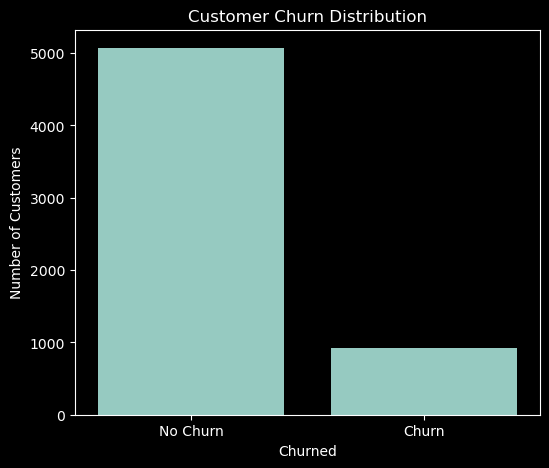

In [13]:
#Create churn distribution plot
plt.figure(figsize=(6,5))

sns.countplot(
    x='churned',
    data=df
)

# Labels
plt.title("Customer Churn Distribution")
plt.xlabel("Churned")
plt.ylabel("Number of Customers")

# Rename x-axis labels
plt.xticks([0,1], ['No Churn', 'Churn'])

# Show plot
plt.show()

Around 5100 customers remained with the company, while nearly 900 customers churned.
Non-churn customers are significantly higher, indicating strong customer retention.
The large difference between both categories highlights an imbalanced churn distribution.
Churned customers represent a smaller portion of the dataset but indicate potential revenue loss.

## **Statistical Distribution Analysis of E-Commerce Customers**

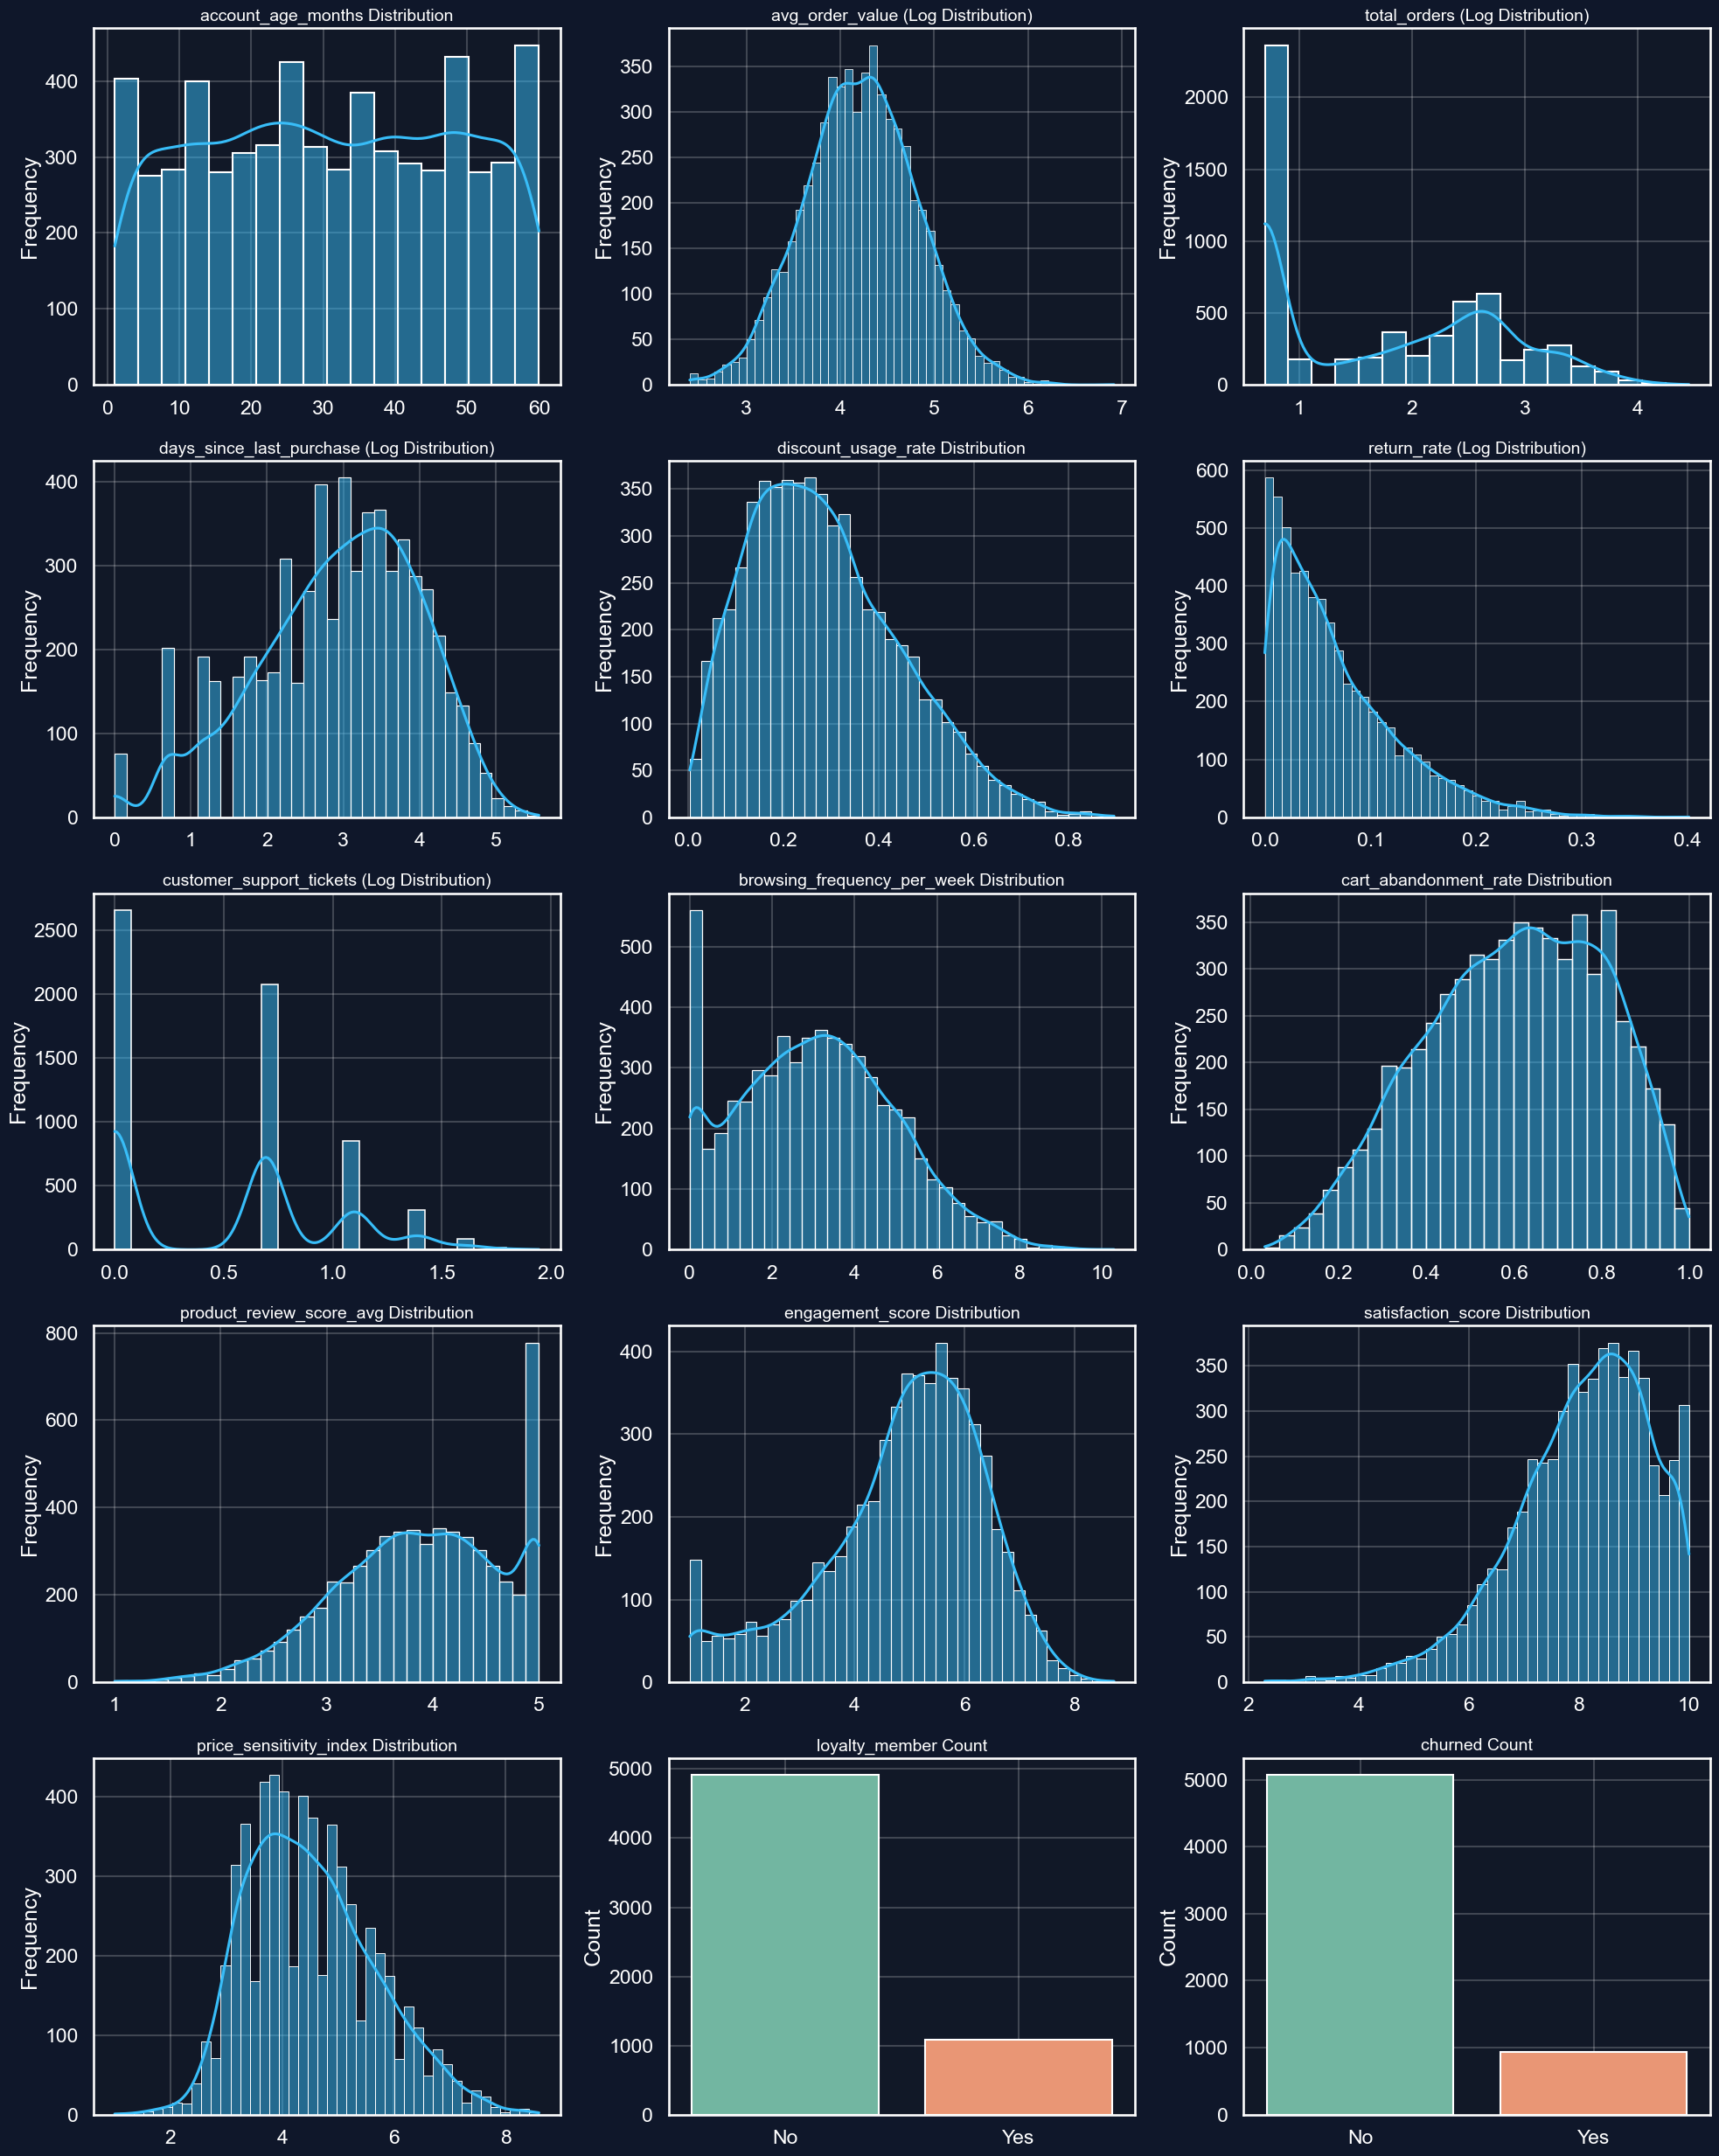

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("e commerce.csv")

# =========================
# 2. COLUMN SETUP
# =========================
categorical_cols = ['loyalty_member', 'churned']

numerical_cols = [
    'account_age_months', 'avg_order_value', 'total_orders',
    'days_since_last_purchase', 'discount_usage_rate', 'return_rate',
    'customer_support_tickets', 'browsing_frequency_per_week',
    'cart_abandonment_rate', 'product_review_score_avg',
    'engagement_score', 'satisfaction_score', 'price_sensitivity_index'
]

all_cols = numerical_cols + categorical_cols

# =========================
# 3. STYLE (MODERN LOOK)
# =========================
sns.set_theme(style="darkgrid", context="talk")

plt.rcParams["figure.facecolor"] = "#0f172a"
plt.rcParams["axes.facecolor"] = "#111827"
plt.rcParams["text.color"] = "white"
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["xtick.color"] = "white"
plt.rcParams["ytick.color"] = "white"

# =========================
# 4. CLEAN DATA FUNCTION
# =========================
def safe_fill(df, col):
    if df[col].dtype != "object":
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna("Unknown")
    return df

for col in all_cols:
    if col in df.columns:
        df = safe_fill(df, col)

# =========================
# 5. PLOTTING FUNCTION
# =========================
def plot_feature_grid(df, columns, num_cols=3):
    rows = math.ceil(len(columns) / num_cols)
    fig, axes = plt.subplots(rows, num_cols, figsize=(20, 5 * rows))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        ax = axes[i]

        # ================= NUMERICAL =================
        if col in numerical_cols:
            skew = df[col].skew()

            if abs(skew) > 1:
                sns.histplot(np.log1p(df[col]), kde=True, ax=ax, color="#38bdf8")
                ax.set_title(f"{col} (Log Distribution)", fontsize=14)
            else:
                sns.histplot(df[col], kde=True, ax=ax, color="#38bdf8")
                ax.set_title(f"{col} Distribution", fontsize=14)

            ax.set_ylabel("Frequency")

        # ================= CATEGORICAL =================
        else:
            order = df[col].value_counts().index

            sns.countplot(
                data=df,
                x=col,
                ax=ax,
                order=order,
                hue=col,          # ✅ FIX for seaborn future warning
                palette="Set2",
                legend=False
            )

            ax.set_title(f"{col} Count", fontsize=14)
            ax.set_ylabel("Count")

        ax.set_xlabel("")
        ax.grid(True, alpha=0.2)

    # ================= REMOVE EMPTY SUBPLOTS =================
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig("univariate_dashboard.png", dpi=300, bbox_inches="tight")
    plt.show()

# =========================
# 6. RUN DASHBOARD
# =========================
plot_feature_grid(df, all_cols)

# **Key Findings from the Graphs**
- The price sensitivity index follows a bell-shaped distribution, with most customers having medium price sensitivity between 4 and 6.
- Very few customers have extremely low or extremely high price sensitivity, indicating balanced customer purchasing behavior.
- The loyalty_member count plot shows that non-loyalty customers are significantly higher than loyalty members.
- This suggests that only a small portion of customers are enrolled in the loyalty program.
- The churned count graph indicates that most customers did not churn, while a smaller group left the platform or service.
 - Since churned customers are lower in number, the business currently has relatively good customer retention performance.

# Bivariate Analysis

# **Impact of Total Orders on Customer Churn**

Average Total Orders:
  churned  total_orders
0      No      8.841057
1     Yes      7.074273


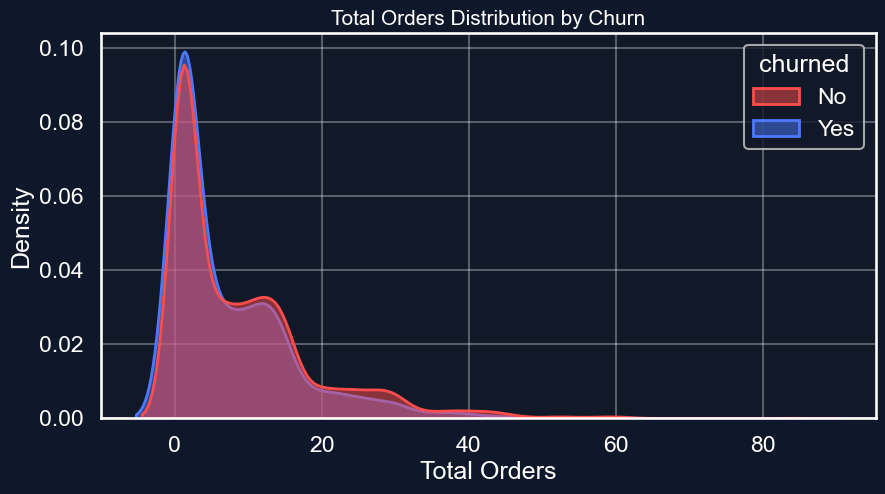

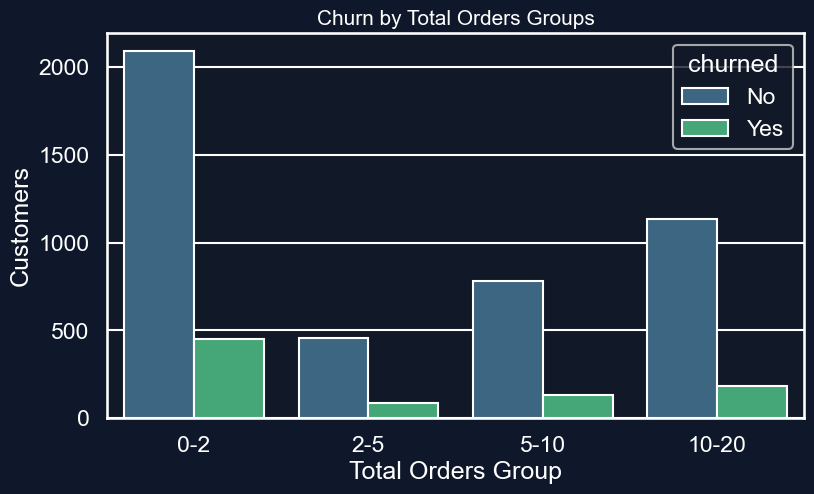


Churn Percentage by Total Orders Group:
churned              No        Yes
orders_group                      
0-2           82.211728  17.788272
2-5           84.375000  15.625000
5-10          85.432640  14.567360
10-20         85.952923  14.047077


In [15]:
# ------------------------------------------
# 1. Average Total Orders by Churn
# ------------------------------------------

avg_orders = df.groupby('churned')['total_orders'].mean().reset_index()

print("Average Total Orders:")
print(avg_orders)

# ------------------------------------------
# 2. Distribution Plot
# ------------------------------------------

plt.figure(figsize=(10,5))

sns.kdeplot(
    data=df,
    x='total_orders',
    hue='churned',
    fill=True,
    common_norm=False,
    palette=['#ff4d4d', '#4d79ff'],
    alpha=0.5,
    linewidth=2
)

plt.title("Total Orders Distribution by Churn", fontsize=15)
plt.xlabel("Total Orders")
plt.ylabel("Density")

plt.grid(alpha=0.3)

plt.show()

# ------------------------------------------
# 3. Total Orders Group Analysis
# ------------------------------------------

df['orders_group'] = pd.cut(
    df['total_orders'],
    bins=[0,2,5,10,20],
    labels=['0-2','2-5','5-10','10-20']
)

plt.figure(figsize=(9,5))

sns.countplot(
    x='orders_group',
    hue='churned',
    data=df,
    palette='viridis'
)

plt.title("Churn by Total Orders Groups", fontsize=15)
plt.xlabel("Total Orders Group")
plt.ylabel("Customers")

plt.show()

# ------------------------------------------
# 4. Churn Percentage Analysis
# ------------------------------------------

orders_percent = pd.crosstab(
    df['orders_group'],
    df['churned'],
    normalize='index'
) * 100

print("\nChurn Percentage by Total Orders Group:")
print(orders_percent)

# **Findings**
- Most customers placed between 0–2 orders, making it the largest customer segment.
- Churned customers are concentrated mainly in the lower order groups, especially 0–2 and 2–5 orders.
- Customers with higher order frequency (10+ orders) show comparatively lower churn levels, indicating stronger customer loyalty.
- The KDE distribution is right-skewed, showing that only a small number of customers placed very high numbers of orders.

## **Customer Inactivity & Churn Behavior Analysis**

Average Days Since Last Purchase:
  churned  days_since_last_purchase
0      No                 20.101952
1     Yes                 81.433800


C:\Users\lenovo\AppData\Local\Temp\ipykernel_11616\3565940274.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


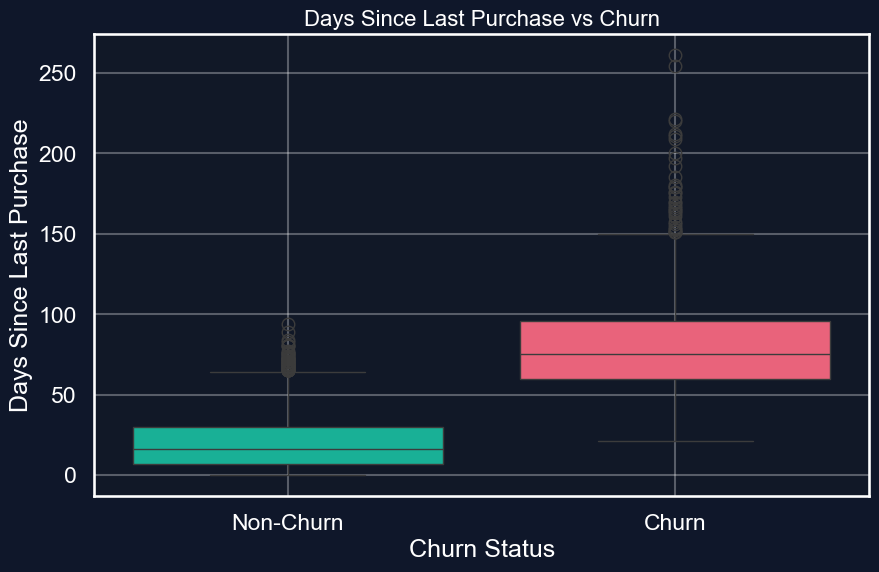

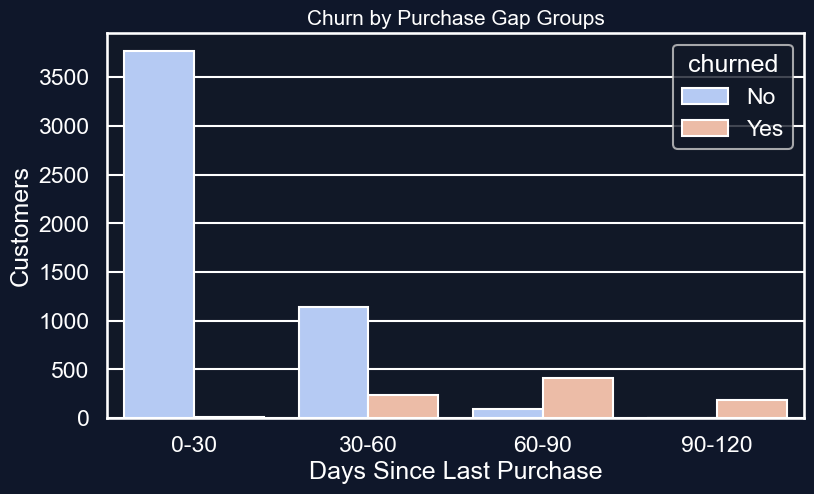


Churn Percentage by Purchase Gap:
churned                    No        Yes
purchase_gap_group                      
0-30                99.814422   0.185578
30-60               82.932166  17.067834
60-90               18.326693  81.673307
90-120               0.543478  99.456522


In [16]:
# ------------------------------------------
# 1. Average Days Since Last Purchase
# ------------------------------------------

avg_days = df.groupby('churned')['days_since_last_purchase'].mean().reset_index()

print("Average Days Since Last Purchase:")
print(avg_days)

# ------------------------------------------
# 2. Box Plot Analysis
# ------------------------------------------

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='churned',
    y='days_since_last_purchase',
    palette=['#00C9A7', '#FF4D6D']
)

plt.title("Days Since Last Purchase vs Churn", fontsize=16)
plt.xlabel("Churn Status")
plt.ylabel("Days Since Last Purchase")

plt.xticks([0,1], ['Non-Churn', 'Churn'])

plt.grid(alpha=0.3)

plt.show()

# ------------------------------------------
# 3. Days Group Analysis
# ------------------------------------------

df['purchase_gap_group'] = pd.cut(
    df['days_since_last_purchase'],
    bins=[0,30,60,90,120],
    labels=['0-30','30-60','60-90','90-120']
)

plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x='purchase_gap_group',
    hue='churned',
    palette='coolwarm'
)

plt.title("Churn by Purchase Gap Groups", fontsize=15)
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Customers")

plt.show()

# ------------------------------------------
# 4. Churn Percentage
# ------------------------------------------

gap_percent = pd.crosstab(
    df['purchase_gap_group'],
    df['churned'],
    normalize='index'
) * 100

print("\nChurn Percentage by Purchase Gap:")
print(gap_percent)

# **Findings**
- Customers with a purchase gap of 0–30 days show the lowest churn rate, meaning frequent buyers are more loyal.
- Churn increases significantly when the days since last purchase exceed 60 days.
- The boxplot shows churned customers have a much higher median purchase gap compared to non-churn customers.
- Customers inactive for 90+ days are highly likely to churn, indicating inactivity is a strong churn indicator.

## **Engagement Score Distribution Analysis by Churn**

Average Engagement Score:
  churned  engagement_score
0      No          5.345155
1     Yes          2.364736


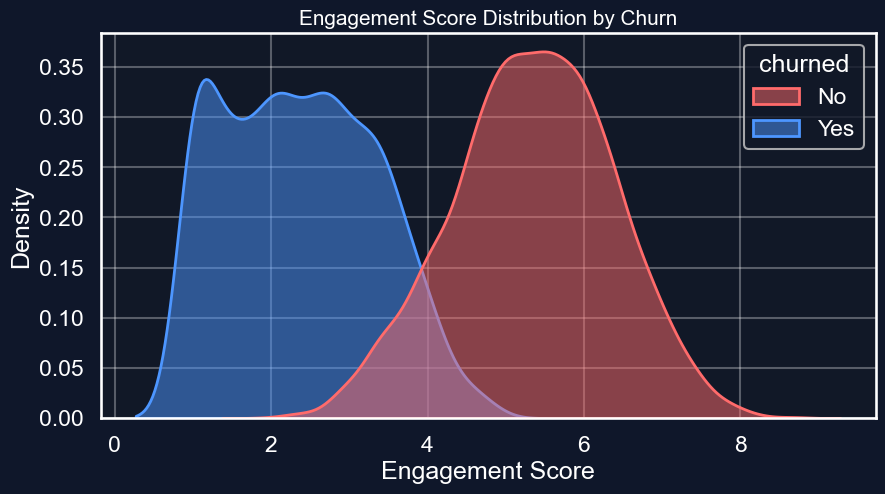

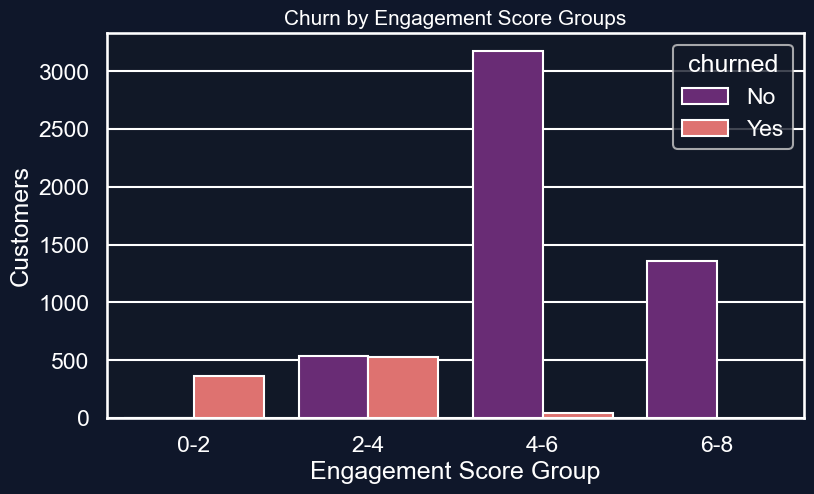


Churn Percentage by Engagement Score:
churned                   No        Yes
engagement_group                       
0-2                 0.273973  99.726027
2-4                50.378072  49.621928
4-6                98.754670   1.245330
6-8               100.000000   0.000000


In [17]:
# ------------------------------------------
# 1. Average Engagement Score
# ------------------------------------------

avg_engagement = df.groupby('churned')['engagement_score'].mean().reset_index()

print("Average Engagement Score:")
print(avg_engagement)

# ------------------------------------------
# 2. KDE Distribution Plot
# ------------------------------------------

plt.figure(figsize=(10,5))

sns.kdeplot(
    data=df,
    x='engagement_score',
    hue='churned',
    fill=True,
    common_norm=False,
    palette=['#FF6B6B', '#4D96FF'],
    alpha=0.5,
    linewidth=2
)

plt.title("Engagement Score Distribution by Churn", fontsize=15)
plt.xlabel("Engagement Score")
plt.ylabel("Density")

plt.grid(alpha=0.3)

plt.show()

# ------------------------------------------
# 3. Engagement Score Group Analysis
# ------------------------------------------

df['engagement_group'] = pd.cut(
    df['engagement_score'],
    bins=[0,2,4,6,8],
    labels=['0-2','2-4','4-6','6-8']
)

plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x='engagement_group',
    hue='churned',
    palette='magma'
)

plt.title("Churn by Engagement Score Groups", fontsize=15)
plt.xlabel("Engagement Score Group")
plt.ylabel("Customers")

plt.show()

# ------------------------------------------
# 4. Churn Percentage Analysis
# ------------------------------------------

engagement_percent = pd.crosstab(
    df['engagement_group'],
    df['churned'],
    normalize='index'
) * 100

print("\nChurn Percentage by Engagement Score:")
print(engagement_percent)

# **Findings**
- Customers with low engagement scores (0–2) show the highest churn rate, indicating poor engagement leads to customer loss.
- Most non-churn customers have engagement scores between 4–6, showing active users are more likely to stay.
- The density plot clearly shows churned customers are concentrated at lower engagement levels compared to retained customers.
- Higher engagement scores are strongly associated with better customer retention and loyalty.

## **Impact of Satisfaction Score on Customer Retention**

Average Satisfaction Score:
  churned  satisfaction_score
0      No            8.140284
1     Yes            7.684553


C:\Users\lenovo\AppData\Local\Temp\ipykernel_11616\2633127652.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


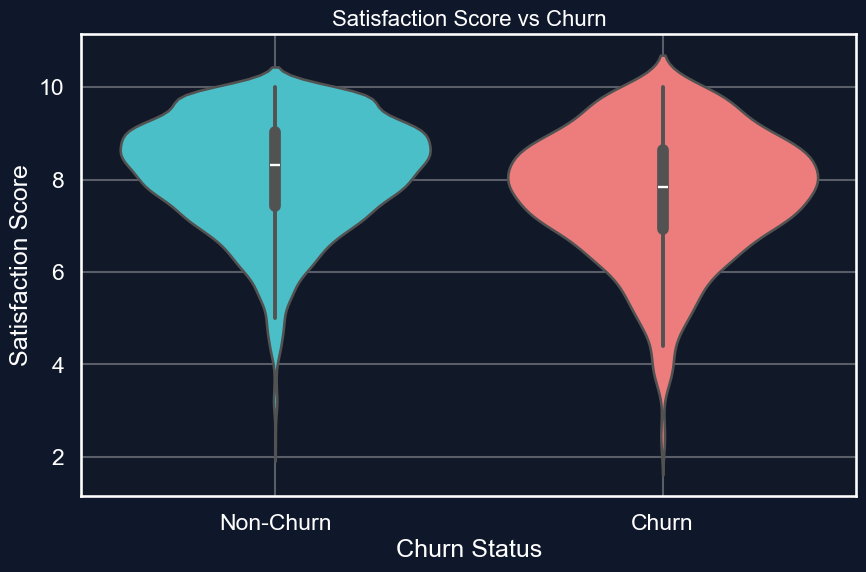

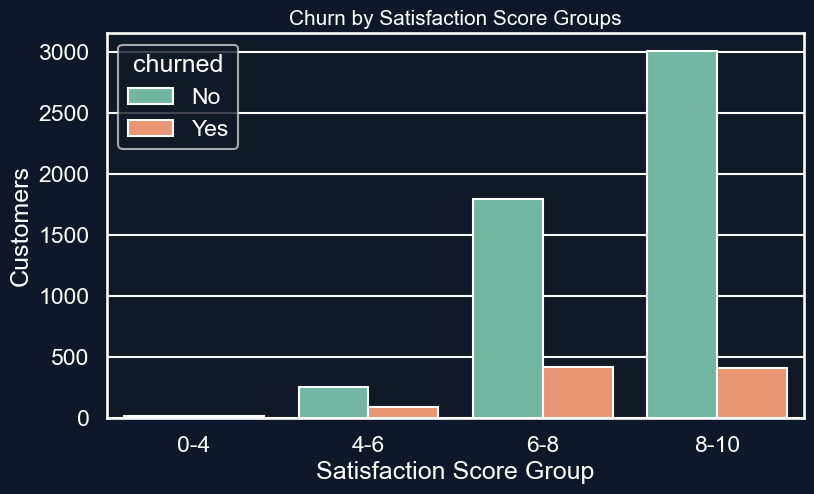


Churn Percentage by Satisfaction Score:
churned                    No        Yes
satisfaction_group                      
0-4                 51.612903  48.387097
4-6                 73.760933  26.239067
6-8                 81.247176  18.752824
8-10                88.016408  11.983592


In [18]:
# ------------------------------------------
# 1. Average Satisfaction Score
# ------------------------------------------

avg_satisfaction = df.groupby('churned')['satisfaction_score'].mean().reset_index()

print("Average Satisfaction Score:")
print(avg_satisfaction)

# ------------------------------------------
# 2. Violin Plot Analysis
# ------------------------------------------

plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='churned',
    y='satisfaction_score',
    palette=['#36D1DC', '#FF6B6B']
)

plt.title("Satisfaction Score vs Churn", fontsize=16)
plt.xlabel("Churn Status")
plt.ylabel("Satisfaction Score")

plt.xticks([0,1], ['Non-Churn', 'Churn'])

plt.grid(alpha=0.3)

plt.show()

# ------------------------------------------
# 3. Satisfaction Score Group Analysis
# ------------------------------------------

df['satisfaction_group'] = pd.cut(
    df['satisfaction_score'],
    bins=[0,4,6,8,10],
    labels=['0-4','4-6','6-8','8-10']
)

plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x='satisfaction_group',
    hue='churned',
    palette='Set2'
)

plt.title("Churn by Satisfaction Score Groups", fontsize=15)
plt.xlabel("Satisfaction Score Group")
plt.ylabel("Customers")

plt.show()

# ------------------------------------------
# 4. Churn Percentage Analysis
# ------------------------------------------

satisfaction_percent = pd.crosstab(
    df['satisfaction_group'],
    df['churned'],
    normalize='index'
) * 100

print("\nChurn Percentage by Satisfaction Score:")
print(satisfaction_percent)

# **Findings**
- Customers with higher satisfaction scores (8–10) have the lowest churn rate, showing satisfied customers are more loyal.
- Churn is comparatively higher among customers with medium satisfaction scores (4–6 and 6–8).
- The violin plot shows non-churn customers are concentrated around higher satisfaction levels than churned customers.
- Customer satisfaction has a strong impact on retention, where lower satisfaction increases the chance of churn.

# **Weekly Browsing Activity Analysis by Churn Status**

Average Browsing Frequency Per Week:
  churned  browsing_frequency_per_week
0      No                     3.172195
1     Yes                     2.555328


C:\Users\lenovo\AppData\Local\Temp\ipykernel_11616\2968555919.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


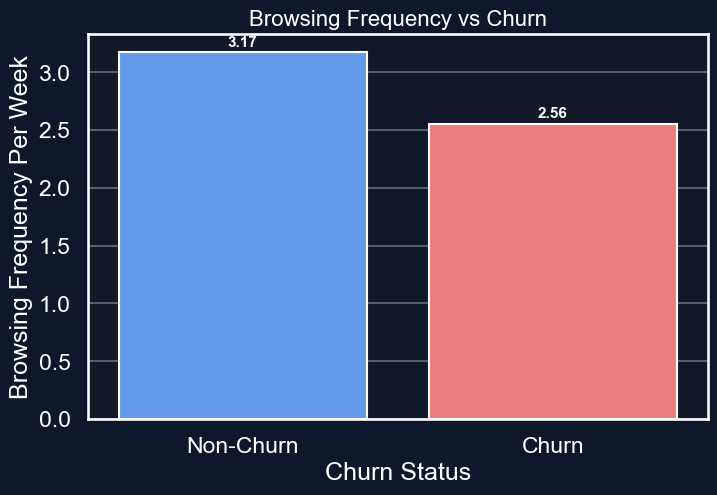

In [19]:
# ------------------------------------------
# Browsing Frequency vs Churn
# ------------------------------------------

avg_browsing = df.groupby('churned')['browsing_frequency_per_week'].mean().reset_index()

print("Average Browsing Frequency Per Week:")
print(avg_browsing)

# ------------------------------------------
# Bar Plot
# ------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    data=avg_browsing,
    x='churned',
    y='browsing_frequency_per_week',
    palette=['#4D96FF', '#FF6B6B']
)

plt.title("Browsing Frequency vs Churn", fontsize=16)
plt.xlabel("Churn Status")
plt.ylabel("Browsing Frequency Per Week")

plt.xticks([0,1], ['Non-Churn', 'Churn'])

# Value Labels
for index, row in avg_browsing.iterrows():
    plt.text(
        index,
        row['browsing_frequency_per_week'] + 0.05,
        round(row['browsing_frequency_per_week'],2),
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.grid(axis='y', alpha=0.3)

plt.show()

# **Findings**
- Non-churn customers have a higher average browsing frequency of 3.17 visits/week compared to churn customers with 2.56 visits/week.
- Customers with more frequent platform visits are more likely to remain active.
- Lower browsing frequency indicates reduced customer engagement and a higher chance of churn.

## **E-Commerce Churn Analysis Using Support Ticket Data**

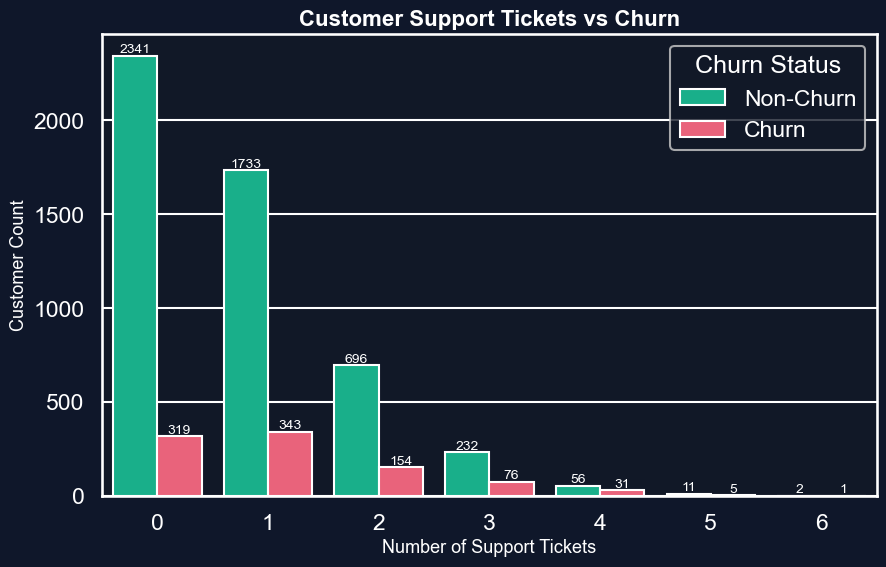

In [20]:
# Remove Extra Spaces from Columns
df.columns = df.columns.str.strip()

# Figure Size
plt.figure(figsize=(10,6))

# Count Plot
ax = sns.countplot(
    data=df,
    x='customer_support_tickets',
    hue='churned',
    palette=['#00C896', '#FF4D6D']
)

# Title & Labels
plt.title('Customer Support Tickets vs Churn',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Number of Support Tickets', fontsize=13)
plt.ylabel('Customer Count', fontsize=13)

# Legend
plt.legend(title='Churn Status',
           labels=['Non-Churn', 'Churn'])

# Add Values on Bars
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.show()

# **Findings**
- Customers with fewer support tickets show the highest retention, while churn increases as support tickets rise.
- Non-churn customers are significantly higher across all ticket categories, indicating better customer satisfaction.
- Customers with multiple support issues are more likely to leave the service, showing support quality impacts churn behavior.

## **Customer Retention Analysis Through Loyalty Programs**

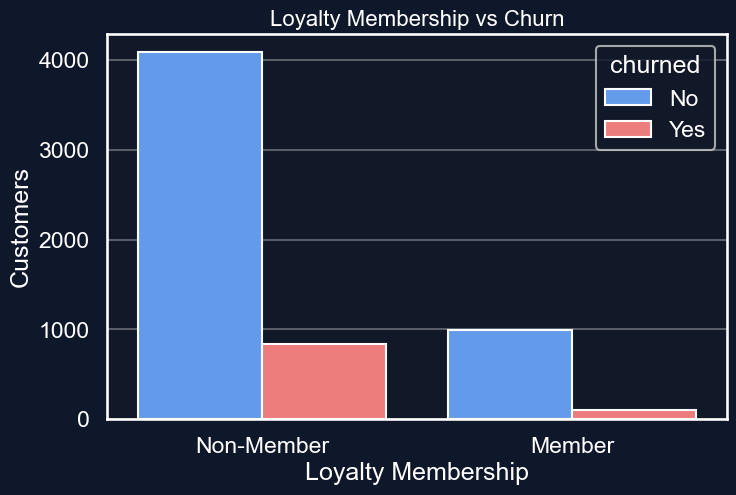


Churn Percentage by Loyalty Membership:
churned                No        Yes
loyalty_member                      
No              83.092574  16.907426
Yes             90.967742   9.032258


In [21]:
# ------------------------------------------
# Loyalty Membership vs Churn
# ------------------------------------------

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='loyalty_member',
    hue='churned',
    palette=['#4D96FF', '#FF6B6B']
)

plt.title("Loyalty Membership vs Churn", fontsize=16)
plt.xlabel("Loyalty Membership")
plt.ylabel("Customers")

plt.xticks([0,1], ['Non-Member', 'Member'])

plt.grid(axis='y', alpha=0.3)

plt.show()

# ------------------------------------------
# Churn Percentage Analysis
# ------------------------------------------

loyalty_percent = pd.crosstab(
    df['loyalty_member'],
    df['churned'],
    normalize='index'
) * 100

print("\nChurn Percentage by Loyalty Membership:")
print(loyalty_percent)

# **Findings**
- Non-members have the highest number of churned customers compared to loyalty members.
- Loyalty members show much lower churn, indicating that membership programs help improve customer retention.
- Most loyal members stayed with the company, while non-members were more likely to leave the platform.

## **E-Commerce Multivariate Customer Behavior Dashboard**

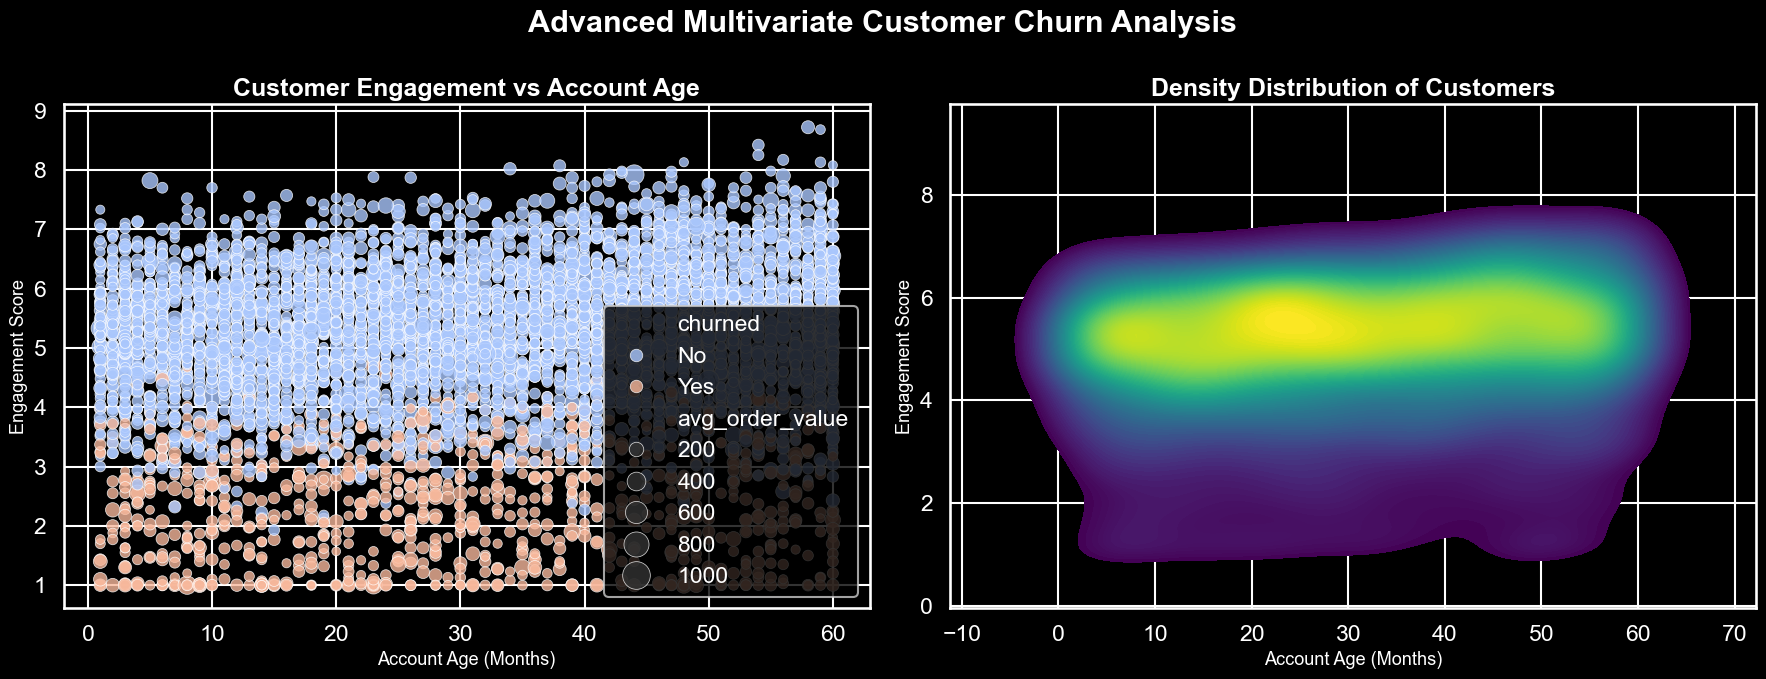

In [22]:


# Style
plt.style.use('dark_background')

# Create Figure
fig, axes = plt.subplots(1, 2, figsize=(18,7))

# =========================
# 🔹 LEFT SIDE : SCATTER PLOT
# =========================

scatter = sns.scatterplot(
    data=df,
    x='account_age_months',
    y='engagement_score',
    hue='churned',
    size='avg_order_value',
    sizes=(40, 400),
    palette='coolwarm',
    alpha=0.8,
    ax=axes[0]
)

axes[0].set_title(
    'Customer Engagement vs Account Age',
    fontsize=18,
    fontweight='bold'
)

axes[0].set_xlabel('Account Age (Months)', fontsize=13)
axes[0].set_ylabel('Engagement Score', fontsize=13)

# =========================
# 🔹 RIGHT SIDE : KDE + CONTOUR STYLE
# =========================

sns.kdeplot(
    data=df,
    x='account_age_months',
    y='engagement_score',
    fill=True,
    cmap='viridis',
    thresh=0.05,
    levels=100,
    ax=axes[1]
)

axes[1].set_title(
    'Density Distribution of Customers',
    fontsize=18,
    fontweight='bold'
)

axes[1].set_xlabel('Account Age (Months)', fontsize=13)
axes[1].set_ylabel('Engagement Score', fontsize=13)

# Main Title
plt.suptitle(
    'Advanced Multivariate Customer Churn Analysis',
    fontsize=22,
    fontweight='bold'
)

# Layout
plt.tight_layout()

# Show
plt.show()

# **Findings**
- Customers with higher engagement scores (around 5–7) mostly did not churn, while customers with lower engagement scores (1–3) showed higher churn behavior.
- Most customers are concentrated between 10–55 months of account age, with engagement scores near 5.5, showing average customer activity is stable.
- Larger bubble sizes indicate higher average order values, and these customers are generally associated with lower churn rates.
- The graph suggests that increasing customer engagement and maintaining long-term accounts can help reduce churn significantly.

## **Interactive Customer Segmentation Using Purchase Behavior**

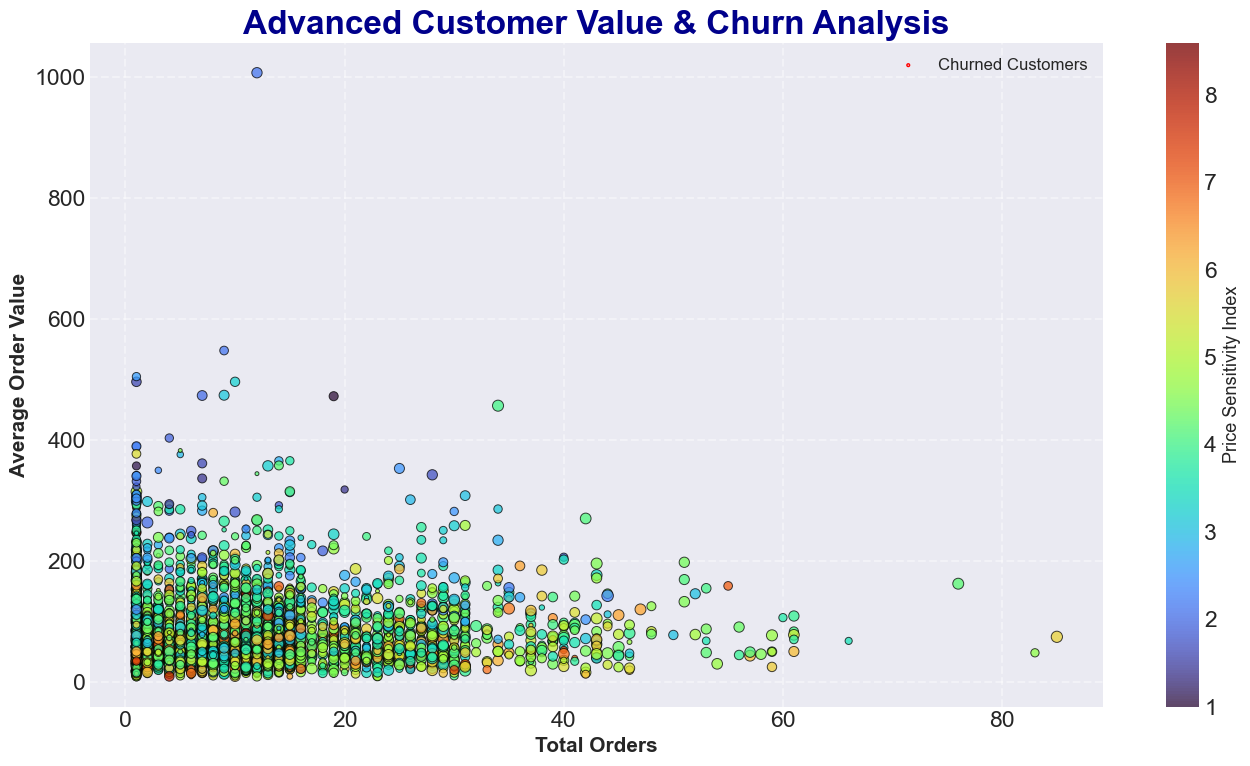

In [25]:

# Modern colorful style
plt.style.use('seaborn-v0_8-darkgrid')

# Figure
plt.figure(figsize=(14,8))

# Bubble Scatter Plot
scatter = plt.scatter(
    df['total_orders'],
    df['avg_order_value'],
    
    # Bubble size
    s=df['engagement_score'] * 8,
    
    # Bubble color
    c=df['price_sensitivity_index'],
    
    # Color map
    cmap='turbo',
    
    alpha=0.75,
    edgecolors='black',
    linewidths=0.7
)

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Price Sensitivity Index', fontsize=13)

# Titles
plt.title(
    'Advanced Customer Value & Churn Analysis',
    fontsize=24,
    fontweight='bold',
    color='darkblue'
)

# Axis Labels
plt.xlabel(
    'Total Orders',
    fontsize=15,
    fontweight='bold'
)

plt.ylabel(
    'Average Order Value',
    fontsize=15,
    fontweight='bold'
)

# Grid
plt.grid(True, linestyle='--', alpha=0.4)

# Churn Highlight
churned = df[df['churned'] == 1]

plt.scatter(
    churned['total_orders'],
    churned['avg_order_value'],
    
    s=churned['engagement_score'] * 10,
    
    facecolors='none',
    edgecolors='red',
    linewidths=2,
    
    label='Churned Customers'
)

# Legend
plt.legend(fontsize=12)

# Tight Layout
plt.tight_layout()

# Show
plt.show()

# **Findings**
- Most customers placed between 0–30 total orders, with average order values mainly ranging from 20–150.
- A few customers have very high average order values above 500, but these cases are rare outliers.
- Customers with higher total orders (40–80+) generally show more stable and moderate spending patterns.
- The Price Sensitivity Index ranges from 1–7, and customers with higher sensitivity are mostly concentrated in lower average order values.

# **Customer Pricing Behavior & Discount Sensitivity Analysis**

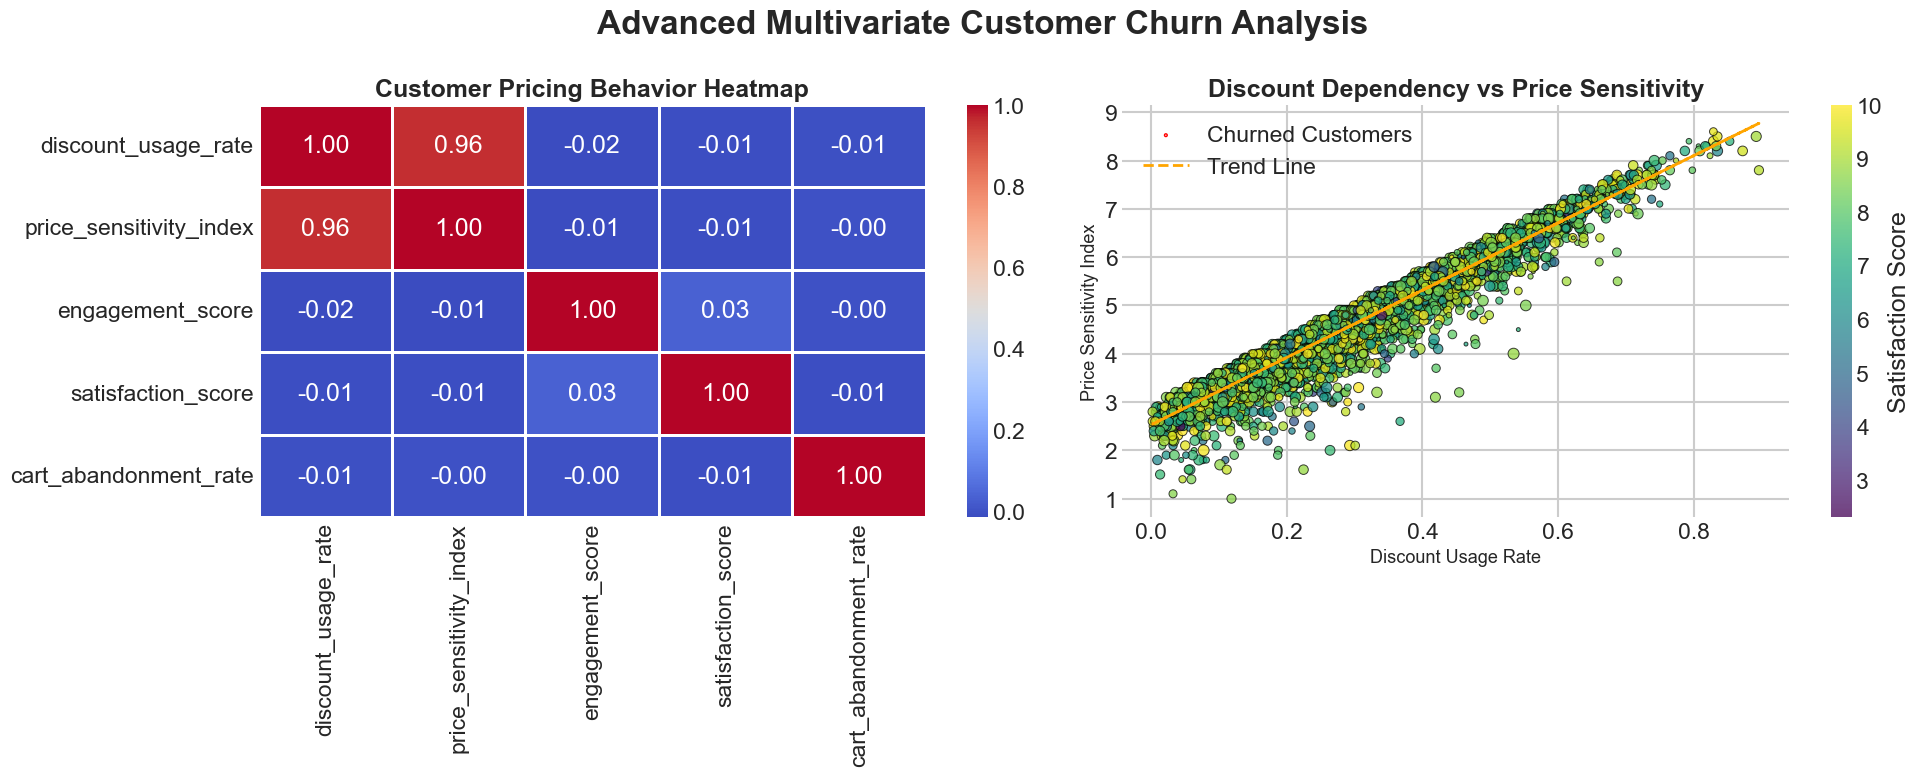

In [27]:
--
# STYLE
# -----------------------------
sns.set_style("whitegrid")

# -----------------------------
# FIGURE
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(20,8))

# =====================================================
# 🔹 HEATMAP
# =====================================================

# Correlation Data
corr_data = df[[
    'discount_usage_rate',
    'price_sensitivity_index',
    'engagement_score',
    'satisfaction_score',
    'cart_abandonment_rate',
    'churned'
]].corr(numeric_only=True)

# Heatmap
sns.heatmap(
    corr_data,
    annot=True,
    cmap='coolwarm',
    linewidths=1,
    fmt='.2f',
    ax=axes[0]
)

axes[0].set_title(
    'Customer Pricing Behavior Heatmap',
    fontsize=18,
    fontweight='bold'
)

# =====================================================
# 🔹 ADVANCED BUBBLE PLOT
# =====================================================

# Convert columns to numeric
x = pd.to_numeric(df['discount_usage_rate'], errors='coerce')
y = pd.to_numeric(df['price_sensitivity_index'], errors='coerce')

bubble_size = pd.to_numeric(
    df['engagement_score'],
    errors='coerce'
).fillna(0) * 8

bubble_color = pd.to_numeric(
    df['satisfaction_score'],
    errors='coerce'
)

# Bubble Scatter Plot
scatter = axes[1].scatter(
    x,
    y,
    s=bubble_size,
    c=bubble_color,
    cmap='viridis',
    alpha=0.75,
    edgecolors='black',
    linewidths=0.7
)

# Highlight churned customers
churned_df = df[df['churned'] == 1]

axes[1].scatter(
    churned_df['discount_usage_rate'],
    churned_df['price_sensitivity_index'],
    
    s=churned_df['engagement_score'] * 10,
    
    facecolors='none',
    edgecolors='red',
    linewidths=2,
    
    label='Churned Customers'
)

# Trend Line
z = np.polyfit(x.dropna(), y.dropna(), 1)
p = np.poly1d(z)

axes[1].plot(
    x,
    p(x),
    linestyle='--',
    linewidth=2,
    color='orange',
    label='Trend Line'
)

# Labels
axes[1].set_title(
    'Discount Dependency vs Price Sensitivity',
    fontsize=18,
    fontweight='bold'
)

axes[1].set_xlabel(
    'Discount Usage Rate',
    fontsize=13
)

axes[1].set_ylabel(
    'Price Sensitivity Index',
    fontsize=13
)

# Colorbar
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('Satisfaction Score')

# Legend
axes[1].legend()

# Main Title
plt.suptitle(
    'Advanced Multivariate Customer Churn Analysis',
    fontsize=24,
    fontweight='bold'
)

# Layout
plt.tight_layout()

# Show Plot
plt.show()

## **Findings**
- The heatmap shows a very strong positive correlation of 0.96 between discount usage rate and price sensitivity index, meaning customers who use - more discounts are highly price-sensitive.
- In the scatter plot, as discount usage increases from 0.0 to 0.9, the price sensitivity index also rises from around 2 to 9.
- Most customer satisfaction scores are concentrated between 6 to 9, even among highly discount-dependent customers.
- Engagement score, satisfaction score, and cart abandonment rate show very weak correlations near 0.00 to 0.03, indicating low direct relationship with pricing behavior.

# **Browsing vs Cart Abandonment Scatter Plot**

C:\Users\lenovo\AppData\Local\Temp\ipykernel_11616\3156691945.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\lenovo\AppData\Local\Temp\ipykernel_11616\3156691945.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


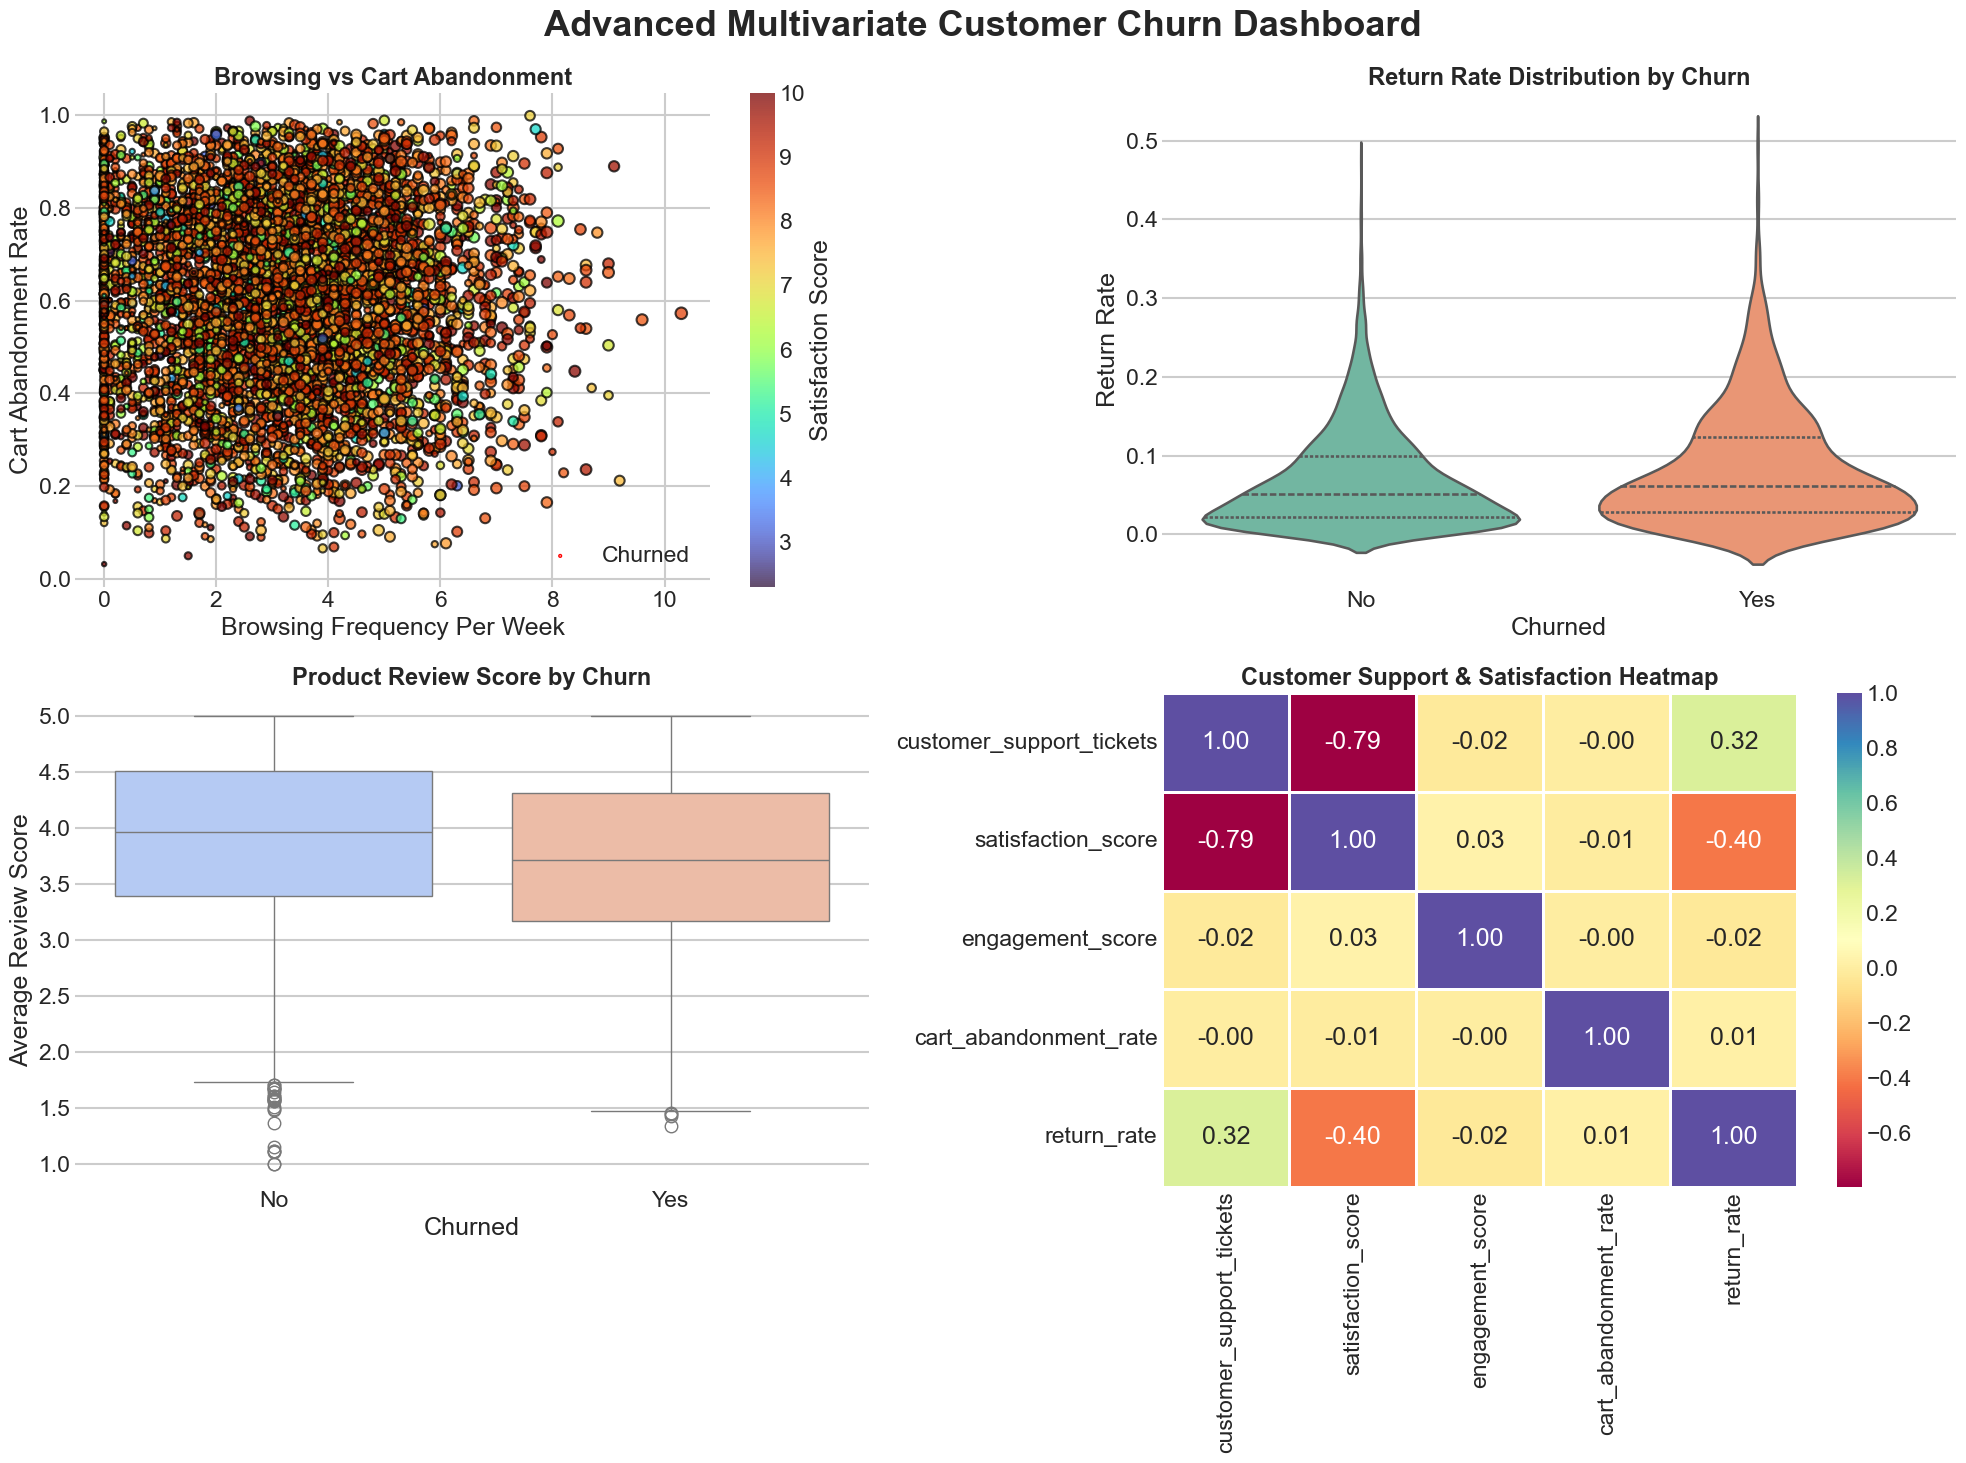

In [28]:
=
# STYLE
# ============================
sns.set_style("whitegrid")

# ============================
# FIGURE
# ============================
fig, axes = plt.subplots(2, 2, figsize=(20,15))

# =====================================================
# 🔹 1. SCATTER + KDE
# Cart Abandonment vs Browsing Frequency
# =====================================================

scatter = axes[0,0].scatter(
    df['browsing_frequency_per_week'],
    df['cart_abandonment_rate'],
    
    s=df['engagement_score'] * 8,
    
    c=df['satisfaction_score'],
    
    cmap='turbo',
    
    alpha=0.75,
    
    edgecolors='black'
)

# Highlight churned customers
churned_df = df[df['churned'] == 1]

axes[0,0].scatter(
    churned_df['browsing_frequency_per_week'],
    churned_df['cart_abandonment_rate'],
    
    s=churned_df['engagement_score'] * 10,
    
    facecolors='none',
    edgecolors='red',
    
    linewidths=2,
    
    label='Churned'
)

axes[0,0].set_title(
    'Browsing vs Cart Abandonment',
    fontsize=17,
    fontweight='bold'
)

axes[0,0].set_xlabel('Browsing Frequency Per Week')
axes[0,0].set_ylabel('Cart Abandonment Rate')

axes[0,0].legend()

# Colorbar
cbar = plt.colorbar(scatter, ax=axes[0,0])
cbar.set_label('Satisfaction Score')

# =====================================================
# 🔹 2. VIOLIN PLOT
# Return Rate vs Product Review Score
# =====================================================

sns.violinplot(
    data=df,
    x='churned',
    y='return_rate',
    
    palette='Set2',
    
    inner='quartile',
    
    ax=axes[0,1]
)

axes[0,1].set_title(
    'Return Rate Distribution by Churn',
    fontsize=17,
    fontweight='bold'
)

axes[0,1].set_xlabel('Churned')
axes[0,1].set_ylabel('Return Rate')

# =====================================================
# 🔹 3. BOXPLOT
# Product Review Score vs Churn
# =====================================================

sns.boxplot(
    data=df,
    x='churned',
    y='product_review_score_avg',
    
    palette='coolwarm',
    
    ax=axes[1,0]
)

axes[1,0].set_title(
    'Product Review Score by Churn',
    fontsize=17,
    fontweight='bold'
)

axes[1,0].set_xlabel('Churned')
axes[1,0].set_ylabel('Average Review Score')

# =====================================================
# 🔹 4. HEATMAP
# Support Tickets + Satisfaction + Churn
# =====================================================

corr_data = df[[
    'customer_support_tickets',
    'satisfaction_score',
    'engagement_score',
    'cart_abandonment_rate',
    'return_rate',
    'churned'
]].corr(numeric_only=True)

sns.heatmap(
    corr_data,
    
    annot=True,
    
    cmap='Spectral',
    
    linewidths=1,
    
    fmt='.2f',
    
    ax=axes[1,1]
)

axes[1,1].set_title(
    'Customer Support & Satisfaction Heatmap',
    fontsize=17,
    fontweight='bold'
)

# =====================================================
# 🔹 MAIN TITLE
# =====================================================

plt.suptitle(
    'Advanced Multivariate Customer Churn Dashboard',
    fontsize=26,
    fontweight='bold'
)

# Layout
plt.tight_layout()

# Show Plot
plt.show()

# Findings
- Customers with browsing frequency between 2 to 6 times per week mostly show cart abandonment rates around 0.4 to 0.9, indicating many users leave products before purchase.
- Churned customers (“Yes”) have a higher return rate mostly between 0.03 to 0.15, while non-churned customers stay closer to 0.01 to 0.08.
- Non-churned customers have a higher average product review score near 4.0 to 4.5, whereas churned customers are mostly around 3.2 to 4.0.
- The heatmap shows a strong negative correlation of -0.79 between customer support tickets and satisfaction score, meaning satisfaction drops when complaints increase.
- Return rate and customer support tickets have a positive correlation of 0.32, showing customers with more returns usually contact support more often.

# Executive Summary

Customer retention is a critical driver of long-term profitability in e-commerce. This report provides a data-driven evaluation of customer churn using transactional metrics, behavioral engagement data, customer service history, and satisfaction indicators.

The analysis reveals that churn is not dictated by a single isolated variable, but rather by a combination of declining platform interaction, unresolved support issues, and low purchase frequencies. By identifying high-risk segments and behavioral thresholds, this report outlines clear, actionable strategies to improve customer retention and maximize customer lifetime value (LTV).

---

# Methodology & Data Preprocessing

To ensure data reliability and maximize analytical accuracy, a structured preprocessing pipeline was implemented before performing exploratory and multivariate analysis.

## Identifier Elimination

The `Customer_ID` column was removed because it acts only as a unique identifier and provides no predictive value. Retaining such columns may lead to overfitting and misleading analytical patterns.

## Categorical Encoding

Categorical variables such as `loyalty_member` and `churned` were transformed into binary numerical values:

- Yes → 1
- No → 0

This conversion enabled smooth statistical analysis and machine learning compatibility.

## Data Quality Audit

A full duplicate-value inspection was conducted to identify and remove redundant observations. Additionally, all column names were standardized into lowercase snake_case formatting to maintain consistency and improve workflow readability.

---

# Key Findings & Behavioral Insights

# A. Core Dataset Composition (Univariate Analysis)

## Class Imbalance

The dataset demonstrates a relatively strong retention baseline, containing approximately **5,100 retained customers** and around **900 churned customers**. Although the churned population is smaller, it represents a major financial leakage that requires targeted intervention.

## Pricing & Loyalty Thresholds

The `price_sensitivity_index` follows an approximately normal distribution concentrated between scores of **4 and 6**, indicating moderate price awareness across the customer base.

However, the `loyalty_member` distribution is heavily skewed toward non-members. This reveals a significant opportunity to improve retention by increasing loyalty-program adoption among casual or first-time buyers.

---

# B. Purchase Recency & Transaction Frequency

## The Inactivity Threshold

Customer inactivity emerged as one of the strongest indicators of churn risk. Churn probability rises sharply when `days_since_last_purchase` exceeds **60 days**. Customers crossing the **90-day inactivity threshold** exhibit extremely high attrition likelihood.

## Transactional Anchors

Most churned customers are concentrated within the lowest purchase-frequency segments, particularly customers with:

- 0–2 lifetime orders
- 2–5 lifetime orders

In contrast, users exceeding **10+ total orders** demonstrate significantly stronger retention and long-term platform stability.

---

# C. Platform Engagement & Digital Friction

## The Engagement Gap

Retained users consistently maintain moderate-to-high engagement scores ranging between **4 and 7**. When the `engagement_score` drops below **3**, churn risk increases substantially.

This trend is also reflected in browsing behavior:

- Active customers average approximately **3.17 browsing sessions per week**
- Churned customers average approximately **2.56 browsing sessions per week**

## The Cart Abandonment Trap

High browsing activity alone does not guarantee retention. A notable segment of customers continues to churn despite frequent platform visits due to elevated `cart_abandonment_rate` values. This indicates the presence of friction during the purchase-decision stage.

---

# D. Service Quality & Experience Management

## The Support Escalation Breakpoint

Customer support interactions play a major role in retention outcomes. Customers with **1–2 support tickets** generally remain stable; however, churn probability increases dramatically once a customer accumulates **3 or more unresolved support interactions**.

This finding highlights operational inefficiencies and unresolved service pain points as major churn drivers.

## Review Sentiment Dynamics

Retained customers are strongly clustered around high satisfaction ranges, particularly review scores between **8 and 10**.

Lower `product_review_score_avg` values correlate closely with elevated return rates and eventual platform abandonment, suggesting that post-purchase dissatisfaction directly contributes to churn.

---

# Advanced Multivariate Deep-Dives

# Pricing Dependency vs. Sensitivity Matrix

A multivariate analysis of:

- `discount_usage_rate`
- `price_sensitivity_index`
- `satisfaction_score`

revealed two distinct behavioral customer segments.

## Value-Driven Brand Loyalists

These customers demonstrate:

- High satisfaction levels
- Low price sensitivity
- Stable engagement behavior
- Consistent purchasing patterns independent of discounts

This segment represents the platform’s most valuable long-term customer base.

## Deal-Chasers (High-Risk Segment)

This segment shows a strong dependency on discounts and promotional incentives. Churned customers are heavily concentrated within this cluster.

Characteristics include:

- High discount usage
- High price sensitivity
- Weak brand loyalty
- Strong competitor-switching behavior

These users are highly likely to leave once promotional incentives decline.

---

# Strategic Recommendations

Based on the findings, the following business strategies are recommended to reduce churn and strengthen customer retention.

## 1. Implement an Automated Win-Back Trigger

Develop an automated retention workflow for customers reaching **45–60 days of inactivity**, especially those with declining engagement patterns.

Recommended actions include:

- Personalized email campaigns
- Targeted discount reminders
- Product recommendations
- Re-engagement notifications

The primary objective should be intervention before customers cross the **90-day churn boundary**.

---

## 2. Standardize a Support Escalation Protocol

Introduce an automated escalation mechanism within the customer support system.

Customers opening a **third support ticket** should be immediately routed to:

- Senior support teams
- Priority-resolution channels
- Retention-focused service agents

This approach can significantly reduce service-induced churn.

---

## 3. Revamp the Loyalty Program Pipeline

Because non-loyalty users account for the majority of churned profiles, the onboarding journey should aggressively encourage early loyalty enrollment.

Potential strategies include:

- Reward-point boosters after the second purchase
- Welcome bonuses
- Exclusive member discounts
- Free-shipping benefits

Strengthening early emotional and financial commitment can improve long-term retention.

---

## 4. Deploy Cart-Abandonment Recovery Workflows

For customers exhibiting:

- High browsing frequency
- High cart abandonment behavior

the platform should launch automated recovery workflows containing:

- Reminder emails
- Real-time customer reviews
- Personalized product recommendations
- Conditional free-shipping offers

These interventions can help eliminate purchase hesitation and improve conversion rates.

##  **Business Conclusion:-**

The analysis shows that customer churn is strongly influenced by low satisfaction scores, high return rates, and frequent customer support issues. Customers who depend heavily on discounts are also more price-sensitive, increasing the risk of churn when offers are reduced. High cart abandonment behavior indicates hesitation during purchase decisions, while lower product review scores reflect poor customer experience. Businesses should focus on improving customer support quality, enhancing product satisfaction, and providing targeted retention offers to reduce churn and increase customer loyalty.